# Importing Libraries & Dataset:

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("powerplant_data.csv")

In [ ]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [ ]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


The Dataset is already pre-processed.

In [ ]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [ ]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


# Splitting and Scaling of Data:-

In [ ]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df.shape

(9568, 5)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

# Convert the dataset into Tensors and then store into DataLoader:-

In [ ]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
type(X_train_scaled)

numpy.ndarray

In [ ]:
type(y_train)
y_train.shape

(7654,)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning Implementation:

In [ ]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 206143.54563802082 & val loss = 204423.984375
epoch 2/100 ==> train loss = 199151.94088541667 & val loss = 189465.59375
epoch 3/100 ==> train loss = 170925.00208333333 & val loss = 147995.828125
epoch 4/100 ==> train loss = 119749.82884114583 & val loss = 91497.7109375
epoch 5/100 ==> train loss = 66808.99436848958 & val loss = 46568.93359375
epoch 6/100 ==> train loss = 33572.844018554686 & val loss = 24398.87890625
epoch 7/100 ==> train loss = 19088.734973144532 & val loss = 15405.90234375
epoch 8/100 ==> train loss = 13145.875602213542 & val loss = 11364.2314453125
epoch 9/100 ==> train loss = 10125.426588948567 & val loss = 8772.115234375
epoch 10/100 ==> train loss = 7804.20532836914 & val loss = 6653.74853515625
epoch 11/100 ==> train loss = 5858.212543741862 & val loss = 4895.3876953125
epoch 12/100 ==> train loss = 4252.532762654622 & val loss = 3501.566162109375
epoch 13/100 ==> train loss = 2993.70694732666 & val loss = 2434.852294921875
epoch 14/

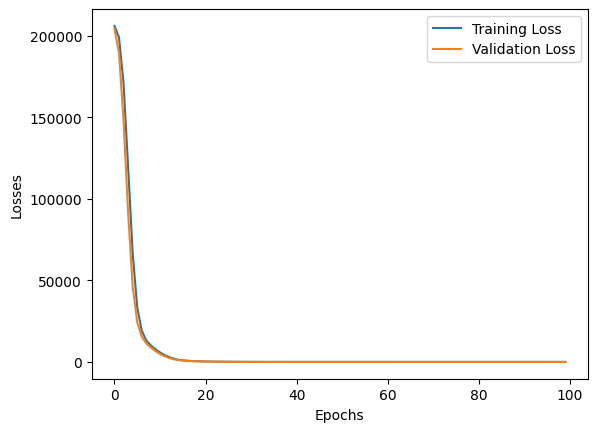

In [ ]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [ ]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [ ]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.484460830688477
Testing MSE: 18.904083251953125


In [ ]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9339351147698396


In [ ]:
X_test

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24
...,...,...,...,...
7204,20.46,51.43,1010.06,83.79
1599,29.70,67.17,1007.31,66.56
5697,14.64,39.58,1011.46,71.90
350,29.47,71.32,1008.07,67.00


In [ ]:
y_test[2513]

np.float64(433.27)

In [ ]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.453766,433.27
1,437.007904,438.16
2,461.626190,458.42
3,476.471222,480.82
4,435.694733,441.41
...,...,...
1909,451.413727,456.70
1910,431.784821,438.04
1911,467.693634,467.80
1912,431.216644,437.14


# Deployment:

In [ ]:
import joblib
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [ ]:
# ============================
# 🔥 IMPORT LIBRARIES
# ============================
import torch
import torch.nn as nn
import gradio as gr
import numpy as np
import joblib  # for loading scaler


# ============================
# 📦 LOAD MODEL + SCALER
# ============================
# Replace with your actual saved paths
MODEL_PATH = "/content/best_model.pt"
SCALER_PATH = "/content/scaler.pkl"

model = ANN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
model.eval()

scaler = joblib.load(SCALER_PATH)


# ============================
# 🔮 PREDICTION FUNCTION
# ============================
def predict_energy(temp, vacuum, pressure, humidity):
    try:
        # Convert input to numpy array
        input_data = np.array([[temp, vacuum, pressure, humidity]])

        # Scale input
        scaled_input = scaler.transform(input_data)

        # Convert to tensor
        tensor_input = torch.tensor(scaled_input, dtype=torch.float32)

        # Model prediction
        with torch.no_grad():
            prediction = model(tensor_input).item()

        # Format output
        return f"{prediction:.2f} MW ⚡"

    except Exception as e:
        return f"Error: {str(e)}"


# ============================
# 🎨 CUSTOM CSS (BLACK + RED THEME)
# ============================
custom_css = """
body {
    background-color: #0d0d0d;
    font-family: 'Segoe UI', sans-serif;
}

.gradio-container {
    background: linear-gradient(145deg, #0d0d0d, #1a1a1a);
    border-radius: 15px;
    padding: 20px;
}

h1 {
    color: #ff1a1a;
    text-align: center;
    font-weight: bold;
}

.section {
    background: #1a1a1a;
    padding: 15px;
    border-radius: 12px;
    margin-bottom: 15px;
    box-shadow: 0px 0px 15px rgba(255, 0, 0, 0.2);
}

.output-box {
    background: black;
    color: #00ffcc;
    font-size: 28px;
    text-align: center;
    padding: 20px;
    border-radius: 12px;
    border: 2px solid red;
}

button {
    background: linear-gradient(90deg, #ff0000, #cc0000);
    color: white !important;
    font-weight: bold;
    border-radius: 10px !important;
}

button:hover {
    background: linear-gradient(90deg, #ff4d4d, #990000);
    transform: scale(1.05);
}
"""


# ============================
# 🧩 GRADIO UI
# ============================
with gr.Blocks(css=custom_css) as app:

    # 🔥 HEADER
    gr.HTML("<h1>⚡ Power Plant Energy Predictor (ANN)</h1>")

    gr.Markdown(
        "### Enter environmental conditions to predict energy output using a trained Neural Network"
    )

    # INPUT SECTION
    with gr.Row():
        with gr.Column(scale=1):
            gr.HTML("<div class='section'>")

            temp = gr.Slider(0, 50, label="🌡 Temperature (°C)", value=25)
            vacuum = gr.Slider(25, 100, label="🌀 Vacuum", value=50)
            pressure = gr.Slider(900, 1100, label="🔵 Pressure (mbar)", value=1000)
            humidity = gr.Slider(0, 100, label="💧 Humidity (%)", value=50)

            gr.HTML("</div>")

    # PREDICT BUTTON
    predict_btn = gr.Button("🚀 Predict Energy")

    # OUTPUT SECTION
    output = gr.HTML("<div class='output-box'>Prediction will appear here</div>")

    # FUNCTION BINDING
    def styled_output(temp, vacuum, pressure, humidity):
        result = predict_energy(temp, vacuum, pressure, humidity)
        return f"<div class='output-box'>{result}</div>"

    predict_btn.click(
        fn=styled_output,
        inputs=[temp, vacuum, pressure, humidity],
        outputs=output
    )


# ============================
# ▶️ LAUNCH APP
# ============================
if __name__ == "__main__":
    app.launch()

/tmp/ipykernel_7795/3719838222.py:106: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://335f623202d42dbe0e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
